In [3]:
import sys

!{sys.executable} -m pip uninstall -y torch torchvision torchaudio segmentation-models-pytorch timm pretrainedmodels efficientnet-pytorch

!{sys.executable} -m pip install -q \
  torch==2.4.1 \
  torchvision==0.19.1 \
  torchaudio==2.4.1 \
  --index-url https://download.pytorch.org/whl/cu118

!{sys.executable} -m pip install -q \
  segmentation-models-pytorch==0.3.4 \
  timm==0.9.7 \
  pretrainedmodels==0.7.4 \
  efficientnet-pytorch==0.7.1


Found existing installation: torch 2.4.1+cu118
Uninstalling torch-2.4.1+cu118:
  Successfully uninstalled torch-2.4.1+cu118
Found existing installation: torchvision 0.19.1+cu118
Uninstalling torchvision-0.19.1+cu118:
  Successfully uninstalled torchvision-0.19.1+cu118
Found existing installation: torchaudio 2.4.1+cu118
Uninstalling torchaudio-2.4.1+cu118:
  Successfully uninstalled torchaudio-2.4.1+cu118
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [4]:
import random
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision
import segmentation_models_pytorch as smp

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=6,
).cuda()

x = torch.randn(2, 1, 256, 256).cuda()
y = model(x)

print(y.shape)
print("DEEPLAB CUDA OK")
# =========================
# PATHS
# =========================

DATASET_DIR = Path(
    "/kaggle/input/datasets/matanerdy/arkheologic/dataset_5_classes_multiclass"
)

DATA_PATH = DATASET_DIR / "metadata.csv"
IMAGES_DIR = DATASET_DIR / "images"
MASKS_DIR = DATASET_DIR / "masks"


# =========================
# CLASSES
# =========================

CLASS_TO_ID = {
    "background": 0,
    "kurgany_tselye": 1,
    "kurgany_povrezhdennye": 2,
    "gorodishcha": 3,
    "fortifikatsii": 4,
    "arkhitektury": 5,
}

ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
NUM_CLASSES = len(CLASS_TO_ID)
IGNORE_INDEX = 255


# =========================
# MODELS
# =========================

class DeepLabMultiClass(nn.Module):
    def __init__(
        self,
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=1,
        classes=NUM_CLASSES,
    ):
        super().__init__()

        if smp is None:
            raise ImportError(
                "segmentation_models_pytorch is not installed. "
                "Install it or use UNetSmall instead."
            )

        self.model = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
        )

    def forward(self, x):
        return self.model(x)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels=1, out_channels=NUM_CLASSES):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


# =========================
# DATASET
# =========================

class ArcheologyDatasetMultiClass(Dataset):
    def __init__(
        self,
        meta_df,
        images_dir,
        masks_dir,
        target_size=256,
        normalize="zscore",
        transform=None,
        validate_masks=True,
    ):
        self.meta = meta_df.reset_index(drop=True).copy()
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.target_size = target_size
        self.normalize = normalize
        self.transform = transform
        self.validate_masks = validate_masks

    def __len__(self):
        return len(self.meta)

    def _normalize_patch(self, patch: np.ndarray) -> np.ndarray:
        patch = patch.astype(np.float32)

        if self.normalize == "zscore":
            mean = patch.mean()
            std = patch.std()
            if std < 1e-6:
                std = 1.0
            patch = (patch - mean) / std

        elif self.normalize == "minmax":
            pmin = patch.min()
            pmax = patch.max()
            if pmax - pmin < 1e-6:
                patch = np.zeros_like(patch, dtype=np.float32)
            else:
                patch = (patch - pmin) / (pmax - pmin)

        elif self.normalize is None:
            pass
        else:
            raise ValueError(f"Unknown normalize mode: {self.normalize}")

        return patch

    @staticmethod
    def _format_sample_id(value) -> str:
        # metadata.csv может прочитать sample_id как int или как строку.
        return str(value).zfill(6)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        sample_id = self._format_sample_id(row["sample_id"])

        patch = np.load(self.images_dir / f"{sample_id}.npy")
        mask = np.load(self.masks_dir / f"{sample_id}.npy")

        orig_h, orig_w = patch.shape

        if self.target_size is not None:
            if patch.shape != (self.target_size, self.target_size):
                patch = cv2.resize(
                    patch,
                    (self.target_size, self.target_size),
                    interpolation=cv2.INTER_LINEAR,
                )

            if mask.shape != (self.target_size, self.target_size):
                mask = cv2.resize(
                    mask,
                    (self.target_size, self.target_size),
                    interpolation=cv2.INTER_NEAREST,
                )

        if self.transform is not None:
            patch, mask = self.transform(patch, mask)

        patch = np.asarray(patch, dtype=np.float32)
        mask = np.asarray(mask, dtype=np.int64)

        if self.validate_masks:
            unique_vals = np.unique(mask)
            valid_ids = set(CLASS_TO_ID.values())
            bad_vals = [int(v) for v in unique_vals if int(v) not in valid_ids]
            if bad_vals:
                raise ValueError(
                    f"Unexpected mask values for sample {sample_id}: {unique_vals}. "
                    f"Expected ids: {sorted(valid_ids)}"
                )

        patch = self._normalize_patch(patch)

        image_tensor = torch.from_numpy(patch).float().unsqueeze(0)  # [1, H, W]
        mask_tensor = torch.from_numpy(mask).long()                 # [H, W]

        sample = {
            "image": image_tensor,
            "mask": mask_tensor,
            "sample_id": sample_id,
            "region": row["region"],
            "modality": row["modality"],
            "raster_file": row["raster_file"],
            "class_name": row["class_name"],
            "class_id": int(row["class_id"]) if "class_id" in row.index else CLASS_TO_ID[row["class_name"]],
            "n_objects_in_patch": int(row["n_objects_in_patch"]),
            "orig_height": int(orig_h),
            "orig_width": int(orig_w),
            "input_height": int(image_tensor.shape[-2]),
            "input_width": int(image_tensor.shape[-1]),
        }

        optional_cols = [
            "used_crs_fallback",
            "touches_border",
            "crop_size",
            "obj_w_px",
            "obj_h_px",
            "target_fits_inside",
            "mask_bg_pixels",
            "mask_kurgany_tselye_pixels",
            "mask_kurgany_povrezhdennye_pixels",
            "mask_gorodishcha_pixels",
            "mask_fortifikatsii_pixels",
            "mask_arkhitektury_pixels",
            "has_kurgany_tselye",
            "has_kurgany_povrezhdennye",
            "has_gorodishcha",
            "has_fortifikatsii",
            "has_arkhitektury",
        ]
        for col in optional_cols:
            if col in row.index:
                sample[col] = row[col]

        return sample

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6, include_background=False):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.include_background = include_background

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)

        target_one_hot = F.one_hot(
            targets.clamp(0, self.num_classes - 1),
            num_classes=self.num_classes,
        ).permute(0, 3, 1, 2).float()

        class_ids = range(self.num_classes) if self.include_background else range(1, self.num_classes)

        losses = []
        for cls_id in class_ids:
            p = probs[:, cls_id]
            t = target_one_hot[:, cls_id]

            inter = (p * t).sum(dim=(1, 2))
            union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))

            dice = (2 * inter + self.smooth) / (union + self.smooth)
            losses.append(1 - dice)

        return torch.stack(losses).mean()


class CombinedMultiClassLoss(nn.Module):
    def __init__(
        self,
        ce_weight=0.7,
        dice_weight=0.3,
        class_weights=None,
        include_background_in_dice=False,
    ):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

        if class_weights is not None:
            class_weights = class_weights.clone().detach().float()
        self.register_buffer("class_weights", class_weights)

        self.dice = MultiClassDiceLoss(
            num_classes=NUM_CLASSES,
            include_background=include_background_in_dice,
        )

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets.long(),
            weight=self.class_weights,
        )

        dice = self.dice(logits, targets.long())

        loss = self.ce_weight * ce + self.dice_weight * dice

        return loss, {
            "ce": ce.detach().item(),
            "dice": dice.detach().item(),
        }

# =========================
# METRICS
# =========================

@torch.no_grad()
def multiclass_confusion_matrix(logits, targets, num_classes=NUM_CLASSES, ignore_index=None):
    preds = torch.argmax(logits, dim=1)  # [B, H, W]

    preds = preds.view(-1)
    targets = targets.view(-1)

    if ignore_index is not None:
        valid = targets != ignore_index
        preds = preds[valid]
        targets = targets[valid]

    valid = (targets >= 0) & (targets < num_classes)
    preds = preds[valid]
    targets = targets[valid]

    indices = targets * num_classes + preds
    cm = torch.bincount(indices, minlength=num_classes * num_classes)
    cm = cm.reshape(num_classes, num_classes).float()
    return cm


def metrics_from_confusion_matrix(cm, smooth=1e-6):
    tp = torch.diag(cm)
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp

    iou = (tp + smooth) / (tp + fp + fn + smooth)
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)

    return {
        "iou_per_class": iou.cpu().numpy(),
        "dice_per_class": dice.cpu().numpy(),
        "mean_iou_fg": iou[1:].mean().item(),
        "mean_dice_fg": dice[1:].mean().item(),
        "mean_iou_all": iou.mean().item(),
        "mean_dice_all": dice.mean().item(),
    }


@torch.no_grad()
def evaluate_multiclass(model, loader, criterion, device, num_classes=NUM_CLASSES, ignore_index=None):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    total_cm = torch.zeros((num_classes, num_classes), dtype=torch.float32, device=device)

    loss_parts_sum = {}

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        logits = model(images)
        loss, loss_parts = criterion(logits, masks)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        for k, v in loss_parts.items():
            loss_parts_sum[k] = loss_parts_sum.get(k, 0.0) + float(v) * batch_size

        cm = multiclass_confusion_matrix(
            logits,
            masks,
            num_classes=num_classes,
            ignore_index=ignore_index,
        ).to(device)
        total_cm += cm

    if total_samples == 0:
        result = {
            "loss": float("nan"),
            "mean_iou_fg": float("nan"),
            "mean_dice_fg": float("nan"),
            "mean_iou_all": float("nan"),
            "mean_dice_all": float("nan"),
        }
        for cls_name in CLASS_TO_ID:
            result[f"{cls_name}_iou"] = float("nan")
            result[f"{cls_name}_dice"] = float("nan")
        return result

    metric_dict = metrics_from_confusion_matrix(total_cm)

    result = {
        "loss": total_loss / total_samples,
        "mean_iou_fg": metric_dict["mean_iou_fg"],
        "mean_dice_fg": metric_dict["mean_dice_fg"],
        "mean_iou_all": metric_dict["mean_iou_all"],
        "mean_dice_all": metric_dict["mean_dice_all"],
    }

    for k, v in loss_parts_sum.items():
        result[k] = v / total_samples

    iou_per_class = metric_dict["iou_per_class"]
    dice_per_class = metric_dict["dice_per_class"]

    for cls_id, cls_name in ID_TO_CLASS.items():
        result[f"{cls_name}_iou"] = float(iou_per_class[cls_id])
        result[f"{cls_name}_dice"] = float(dice_per_class[cls_id])

    return result

# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_default_class_weights(device=None):

    weights = torch.tensor([0.1, 1.0, 1.2, 2, 2.5, 2], dtype=torch.float32)
    if device is not None:
        weights = weights.to(device)
    return weights


torch: 2.4.1+cu118
cuda: 11.8
gpu: Tesla P100-PCIE-16GB
capability: (6, 0)
torch.Size([2, 6, 256, 256])
DEEPLAB CUDA OK


In [5]:
import pandas as pd

meta = pd.read_csv(DATA_PATH)

meta

,sample_id,region,modality,raster_file,source_file,class_name,class_id,class_label_ru,n_objects_in_patch,classes_in_patch,...,mask_kurgany_tselye_pixels,has_kurgany_tselye,mask_kurgany_povrezhdennye_pixels,has_kurgany_povrezhdennye,mask_gorodishcha_pixels,has_gorodishcha,mask_fortifikatsii_pixels,has_fortifikatsii,mask_arkhitektury_pixels,has_arkhitektury
0,0,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,Демидовка_Li_городища.geojson,gorodishcha,3,городища,1,gorodishcha,...,0,False,0,False,380433,True,0,False,0,False
1,1,004_ДЕМИДОВКА,Li,03_Демидовка_Li_карты_g.tif,Демидовка_Li_городища.geojson,gorodishcha,3,городища,1,gorodishcha,...,0,False,0,False,210074,True,0,False,0,False
2,2,004_ДЕМИДОВКА,SpOr,01_Демидовка_SpOr_спутник.tiff,Демидовка_SpOr_городища.geojson,gorodishcha,3,городища,1,gorodishcha,...,0,False,0,False,6049,True,0,False,0,False
3,3,005_ЛУБНО,Li,03_Лубно_Li_карты_g.tif,Лубно_Li_городища.geojson,gorodishcha,3,городища,5,fortifikatsii;gorodishcha,...,0,False,0,False,337129,True,221839,True,0,False
4,4,005_ЛУБНО,Li,03_Лубно_Li_карты_g.tif,Лубно_Li_фортификации.geojson,fortifikatsii,4,фортификации,3,fortifikatsii,...,0,False,0,False,0,False,247253,True,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3255,3255,153_Постройки_4,SpOr,01_Постройки_4_SpOr_спутник.tif,Постройки_4_SpOr_архитектуры.geojson,arkhitektury,5,архитектуры,1,arkhitektury,...,0,False,0,False,0,False,0,False,26672,True
3256,3256,154_Постройки_5,SpOr,01_Постройки_5_SpOr_спутник.tif,Постройки_5_SpOr_архитектуры.geojson,arkhitektury,5,архитектуры,2,arkhitektury,...,0,False,0,False,0,False,0,False,12647,True
3257,3257,154_Постройки_5,SpOr,01_Постройки_5_SpOr_спутник.tif,Постройки_5_SpOr_архитектуры.geojson,arkhitektury,5,архитектуры,3,arkhitektury,...,0,False,0,False,0,False,0,False,20011,True
3258,3258,154_Постройки_5,SpOr,01_Постройки_5_SpOr_спутник.tif,Постройки_5_SpOr_архитектуры.geojson,arkhitektury,5,архитектуры,2,arkhitektury,...,0,False,0,False,0,False,0,False,7452,True


In [6]:
meta.columns


Index(['sample_id', 'region', 'modality', 'raster_file', 'source_file',
       'class_name', 'class_id', 'class_label_ru', 'n_objects_in_patch',
       'classes_in_patch', 'height', 'width', 'crop_size', 'obj_w_px',
       'obj_h_px', 'target_fits_inside', 'touches_border', 'used_crs_fallback',
       'mask_bg_pixels', 'mask_kurgany_tselye_pixels', 'has_kurgany_tselye',
       'mask_kurgany_povrezhdennye_pixels', 'has_kurgany_povrezhdennye',
       'mask_gorodishcha_pixels', 'has_gorodishcha',
       'mask_fortifikatsii_pixels', 'has_fortifikatsii',
       'mask_arkhitektury_pixels', 'has_arkhitektury'],
      dtype='object')

In [7]:
pd.crosstab(meta["modality"], meta["n_objects_in_patch"])

n_objects_in_patch,1,2,3,4,5,6,7,8,9,10,...,41,42,48,49,51,61,66,67,68,75
modality,,,,,,,,,,,,,,,,,,,,,
Ae,154,126,65,65,51,68,63,58,57,74,...,0,1,0,1,0,1,1,3,63,1
Li,120,116,72,63,54,61,51,60,43,48,...,0,0,1,0,0,0,0,0,0,0
Or,3,6,11,10,8,4,15,4,5,4,...,0,0,0,0,0,0,0,0,0,0
SpOr,147,126,124,81,62,49,57,42,31,29,...,2,0,0,0,1,0,0,0,0,0


In [8]:
meta.groupby("modality")["height"].describe()

,count,mean,std,min,25%,50%,75%,max
modality,,,,,,,,
Ae,1274.0,465.177394,517.060793,256.0,256.0,293.0,450.0,4096.0
Li,934.0,541.865096,592.889221,256.0,256.0,356.0,512.0,4096.0
Or,76.0,1861.157895,827.992416,372.0,1213.0,1803.0,2310.5,4096.0
SpOr,976.0,266.631148,67.531016,256.0,256.0,256.0,256.0,1184.0


Dataset size: 3260
sample image shape: torch.Size([1, 256, 256])
sample mask shape: torch.Size([256, 256])
sample mask dtype: torch.int64
sample unique values: tensor([0, 4])
batch image shape: torch.Size([16, 1, 256, 256])
batch mask shape: torch.Size([16, 256, 256])
batch mask dtype: torch.int64
batch mask unique values: tensor([0, 1, 2, 3, 4, 5])
classes in shown mask:
0 background
3 gorodishcha


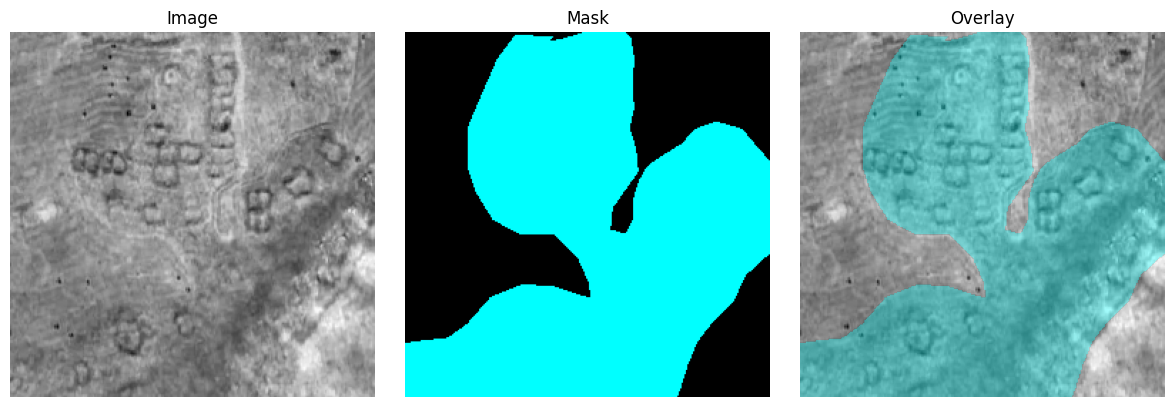

In [9]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap

CLASS_NAMES = {
    0: "background",
    1: "kurgany_tselye",
    2: "kurgany_povrezhdennye",
    3: "gorodishcha",
    4: "fortifikatsii",
    5: "arkhitektury",
}

MASK_CMAP = ListedColormap([
    "black",    # background
    "lime",     # kurgany_tselye
    "red",      # kurgany_povrezhdennye
    "cyan",     # gorodishcha
    "yellow",   # fortifikatsii
    "magenta",  # arkhitektury
])

dataset = ArcheologyDatasetMultiClass(
    meta_df=meta,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

print("Dataset size:", len(dataset))

sample = dataset[4]
print("sample image shape:", sample["image"].shape)   # [1, 256, 256]
print("sample mask shape:", sample["mask"].shape)     # [256, 256]
print("sample mask dtype:", sample["mask"].dtype)      # torch.int64 / long
print("sample unique values:", torch.unique(sample["mask"]))

loader = DataLoader(dataset, batch_size=16, shuffle=True)

batch = next(iter(loader))
print("batch image shape:", batch["image"].shape)     # [B, 1, 256, 256]
print("batch mask shape:", batch["mask"].shape)       # [B, 256, 256]
print("batch mask dtype:", batch["mask"].dtype)
print("batch mask unique values:", torch.unique(batch["mask"]))

img = batch["image"][0, 0].numpy()
msk = batch["mask"][0].numpy()

print("classes in shown mask:")
for cls_id in np.unique(msk):
    print(int(cls_id), CLASS_NAMES[int(cls_id)])

overlay = np.zeros((*msk.shape, 4), dtype=np.float32)
overlay[msk == 1] = [0.0, 1.0, 0.0, 0.35]
overlay[msk == 2] = [1.0, 0.0, 0.0, 0.35]
overlay[msk == 3] = [0.0, 1.0, 1.0, 0.35]
overlay[msk == 4] = [1.0, 1.0, 0.0, 0.35]
overlay[msk == 5] = [1.0, 0.0, 1.0, 0.35]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(msk, cmap=MASK_CMAP, vmin=0, vmax=5)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def filter_multiclass_metadata(
    meta: pd.DataFrame,
    allowed_modalities=("Li", "Ae", "SpOr"),
    allowed_classes=(
        "kurgany_tselye",
        "kurgany_povrezhdennye",
        "gorodishcha",
        "fortifikatsii",
        "arkhitektury",
    ),
    max_crop_size=2048,
    max_objects_in_patch=40,
    touches_border=False,
):
    meta = meta.copy()

    class_pixel_cols = [
        f"mask_{class_name}_pixels"
        for class_name in allowed_classes
        if f"mask_{class_name}_pixels" in meta.columns
    ]

    if class_pixel_cols:
        meta = meta[meta[class_pixel_cols].sum(axis=1) > 0].copy()

    if "class_name" in meta.columns and allowed_classes is not None:
        meta = meta[meta["class_name"].isin(allowed_classes)].copy()

    if "modality" in meta.columns and allowed_modalities is not None:
        meta = meta[meta["modality"].isin(allowed_modalities)].copy()

    if "crop_size" in meta.columns:
        meta = meta[meta["crop_size"] <= max_crop_size].copy()

    if "n_objects_in_patch" in meta.columns:
        meta = meta[meta["n_objects_in_patch"] <= max_objects_in_patch].copy()

    if "touches_border" in meta.columns and touches_border is not None:
        meta = meta[meta["touches_border"] == touches_border].copy()

    meta = meta.reset_index(drop=True)
    return meta

In [11]:
print(meta["touches_border"].value_counts())
print(meta["modality"].value_counts())
print(meta["class_name"].value_counts())
print(meta["region"].value_counts())

touches_border
False    3038
True      222
Name: count, dtype: int64
modality
Ae      1274
SpOr     976
Li       934
Or        76
Name: count, dtype: int64
class_name
kurgany_povrezhdennye    1822
kurgany_tselye            669
fortifikatsii             473
arkhitektury              218
gorodishcha                78
Name: count, dtype: int64
region
027_ТИМЕРЕВО               885
026_БОРОВИЧИ               194
042_ИЗБОРСК                185
044_ГОЧЕВО                 112
033_МИЛОВИДОВО_0.1км       109
                          ... 
144_Каменные_выкладки_5      1
151_Постройки_2             1
152_Постройки_3             1
153_Постройки_4             1
670_СУДБИЩИ                  1
Name: count, Length: 109, dtype: int64


In [12]:
df_start = filter_multiclass_metadata(
                meta,
                allowed_modalities=("Li", "Ae", "SpOr", "Or"),
                max_crop_size=2048,
                max_objects_in_patch=40,
                touches_border=False,
            )
print(df_start["touches_border"].value_counts())
print(df_start["modality"].value_counts())
print(df_start["class_name"].value_counts())
print(df_start["region"].value_counts())

df_start.groupby("modality")["crop_size"].describe()


touches_border
False    2879
Name: count, dtype: int64
modality
Ae      1173
Li       898
SpOr     763
Or        45
Name: count, dtype: int64
class_name
kurgany_povrezhdennye    1635
kurgany_tselye            576
fortifikatsii             430
arkhitektury              183
gorodishcha                55
Name: count, dtype: int64
region
027_ТИМЕРЕВО               883
026_БОРОВИЧИ               190
044_ГОЧЕВО                 110
042_ИЗБОРСК                101
033_МИЛОВИДОВО_0.1км        94
                          ... 
144_Каменные_выкладки_5      1
151_Постройки_2             1
152_Постройки_3             1
153_Постройки_4             1
670_СУДБИЩИ                  1
Name: count, Length: 104, dtype: int64


,count,mean,std,min,25%,50%,75%,max
modality,,,,,,,,
Ae,1173.0,401.747656,240.569612,256.0,256.0,302.0,446.0,1982.0
Li,898.0,449.365256,312.429103,256.0,256.0,350.0,487.5,1968.0
Or,45.0,1314.000000,405.880636,372.0,1022.0,1262.0,1602.0,2000.0
SpOr,763.0,262.694626,45.030696,256.0,256.0,256.0,256.0,1184.0


In [13]:
df_start["region"].value_counts()

region
027_ТИМЕРЕВО               883
026_БОРОВИЧИ               190
044_ГОЧЕВО                 110
042_ИЗБОРСК                101
033_МИЛОВИДОВО_0.1км        94
                          ... 
144_Каменные_выкладки_5      1
151_Постройки_2             1
152_Постройки_3             1
153_Постройки_4             1
670_СУДБИЩИ                  1
Name: count, Length: 104, dtype: int64

In [14]:
import numpy as np
import pandas as pd

def make_region_holdout_split(
    meta,
    val_frac=0.2,
    group_col="region",
    strat_cols=("class_name", "modality"),
    min_val_per_class=3,
    random_state=42,
    n_trials=5000,
):
    rng = np.random.default_rng(random_state)
    meta = meta.copy()

    target_n = int(len(meta) * val_frac)

    global_dist = (
        meta.groupby(list(strat_cols))
        .size()
        .div(len(meta))
    )

    regions = meta[group_col].value_counts().index.to_list()
    region_sizes = meta[group_col].value_counts().to_dict()

    best_score = float("inf")
    best_regions = None

    for _ in range(n_trials):
        shuffled = regions.copy()
        rng.shuffle(shuffled)

        val_regions = []
        val_n = 0

        for r in shuffled:
            if val_n < target_n:
                val_regions.append(r)
                val_n += region_sizes[r]

        val_df = meta[meta[group_col].isin(val_regions)]

        val_dist = (
            val_df.groupby(list(strat_cols))
            .size()
            .div(len(val_df))
        )

        dist_diff = (
            global_dist.sub(val_dist, fill_value=0)
            .abs()
            .sum()
        )

        size_penalty = abs(len(val_df) - target_n) / len(meta)

        class_counts = val_df["class_name"].value_counts()
        missing_or_tiny_penalty = 0
        for cls in meta["class_name"].unique():
            if class_counts.get(cls, 0) < min_val_per_class:
                missing_or_tiny_penalty += 1

        region_domination = (
            val_df[group_col].value_counts().max() / len(val_df)
        )

        score = (
            dist_diff
            + 2.0 * size_penalty
            + 0.5 * missing_or_tiny_penalty
            + 0.5 * region_domination
        )

        if score < best_score:
            best_score = score
            best_regions = val_regions

    train_df = meta[~meta[group_col].isin(best_regions)].copy()
    val_df = meta[meta[group_col].isin(best_regions)].copy()

    return train_df, val_df, best_regions, best_score

In [47]:
meta = df_start.copy()
meta = meta[meta["modality"].isin(["Li", "Ae", "SpOr"])].copy()

train_df, val_df, val_regions, score = make_region_holdout_split(
    meta,
    val_frac=0.2,
    strat_cols=("class_name", "modality"),
    min_val_per_class=5,
    random_state=42,
)

print("Val regions:")
print(val_regions)

print("Score:", score)

print("Train:", len(train_df))
print(train_df["class_name"].value_counts())
print(train_df["modality"].value_counts())

print("Val:", len(val_df))
print(val_df["class_name"].value_counts())
print(val_df["modality"].value_counts())
print(val_df["region"].value_counts())

Val regions:
['015_ВЫШЕНСКОЕ', '140_Каменные_выкладки_1', '034_НОВОТИТАРОВСКАЯ_1.8км', '122_Курганы_3', '123_Курганы_4', '022_КРАСНОСЕЛЬСКАЯ_0.5км', '008_СЕЛЯНЕ', '144_Каменные_выкладки_5', '030_КОПАНСКОЕ', '081_Тоссор', '074_Ксизово', '044_ГОЧЕВО', '670_СУДБИЩИ', '028_САРАТОВ', '088_Верхний_Карабут', '075_Сары_Булун', '076_Скупая_Полудань', '020_ОСЕЧКИ_2', '095_Кисловодская_котловина_5', '128_Курганы_9', '099_Кисловодская_котловина_9', '051_ВОРОНЕЖ_2', '057_ШИШКИНО', '021_НОВОТИТАРОВСКАЯ', '017_ВЫШЕГЖА', '084_Маяцкая_крепость', '032_ПРИМАКИ_1.3км', '010_НОВЕНЬКОЕ', '082_Солдатское', '037_КЧР', '049_ВОРОНЕЖ_1', '125_Курганы_6']
Score: 0.33741258741258745
Train: 2262
class_name
kurgany_povrezhdennye    1333
kurgany_tselye            408
fortifikatsii             367
arkhitektury              112
gorodishcha                42
Name: count, dtype: int64
modality
Ae      933
Li      698
SpOr    631
Name: count, dtype: int64
Val: 572
class_name
kurgany_povrezhdennye    302
kurgany_tselye   

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
arch_val_df = val_df[val_df["class_name"] == "arkhitektury"]

arch_val_dataset = ArcheologyDatasetMultiClass(
    meta_df=arch_val_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

arch_val_loader = DataLoader(
    arch_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

print_pred_distribution(model, arch_val_loader, device, max_batches=10)

Device: cuda
Predicted pixel distribution:
0: background                    816602 (0.4792)
1: kurgany_tselye                  5891 (0.0035)
2: kurgany_povrezhdennye          14867 (0.0087)
3: gorodishcha                   465448 (0.2732)
4: fortifikatsii                  44104 (0.0259)
5: arkhitektury                  357024 (0.2095)


In [52]:
from torch.utils.data import DataLoader, random_split
from torch.utils.data import WeightedRandomSampler

train_dataset = ArcheologyDatasetMultiClass(
    meta_df=train_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

val_dataset = ArcheologyDatasetMultiClass(
    meta_df=val_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

class_counts = train_dataset.meta["class_name"].value_counts().to_dict()

sample_weights = train_dataset.meta["class_name"].map(
    lambda c: 1.0 / class_counts[c]
).values

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

train_eval_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


In [53]:
batch = next(iter(train_loader))

print(batch["image"].shape)  # [B, 1, 256, 256]
print(batch["mask"].shape)   # [B, 256, 256]
print(torch.unique(batch["mask"]))

torch.Size([16, 1, 256, 256])
torch.Size([16, 256, 256])
tensor([0, 1, 2, 3, 4])


In [54]:
@torch.no_grad()
def print_pred_distribution(model, loader, device, max_batches=3):
    model.eval()

    counts = torch.zeros(NUM_CLASSES, dtype=torch.long)

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        images = batch["image"].to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu()

        for cls_id in range(NUM_CLASSES):
            counts[cls_id] += (preds == cls_id).sum()

    total = counts.sum().item()

    print("Predicted pixel distribution:")
    for cls_id, count in enumerate(counts.tolist()):
        frac = count / max(total, 1)
        print(f"{cls_id}: {ID_TO_CLASS[cls_id]:25s} {count:10d} ({frac:.4f})")

In [55]:
def compute_class_weights(meta, power=0.5):
    counts = meta["class_name"].value_counts()

    # порядок как в модели
    class_order = [
        "background",
        "kurgany_tselye",
        "kurgany_povrezhdennye",
        "gorodishcha",
        "fortifikatsii",
        "arkhitektury",
    ]

    weights = []

    total = counts.sum()

    for cls in class_order:
        if cls == "background":
            weights.append(0.1)
            continue

        c = counts.get(cls, 1)
        w = (total / c) ** power   # <-- мягкое сглаживание
        weights.append(w)

    weights = np.array(weights)
    weights = weights / weights.mean()  # нормализация

    return torch.tensor(weights, dtype=torch.float32)

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        if class_weights is not None:
            class_weights = class_weights.clone().detach().float()
        self.register_buffer("class_weights", class_weights)
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets.long(),
            weight=self.class_weights,
            reduction="none",
        )

        pt = torch.exp(-ce)
        focal = ((1.0 - pt) ** self.gamma) * ce
        return focal.mean()


class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6, include_background=False):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.include_background = include_background

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)

        target_one_hot = F.one_hot(
            targets.long().clamp(0, self.num_classes - 1),
            num_classes=self.num_classes,
        ).permute(0, 3, 1, 2).float()

        class_ids = range(self.num_classes) if self.include_background else range(1, self.num_classes)

        losses = []
        for cls_id in class_ids:
            p = probs[:, cls_id]
            t = target_one_hot[:, cls_id]

            inter = (p * t).sum(dim=(1, 2))
            union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))

            dice = (2 * inter + self.smooth) / (union + self.smooth)
            losses.append(1.0 - dice)

        return torch.stack(losses).mean()


class AntiCollapseMultiClassLoss(nn.Module):
    def __init__(
        self,
        focal_weight=0.6,
        dice_weight=0.4,
        class_weights=None,
        gamma=2.0,
        include_background_in_dice=False,
    ):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

        self.focal = FocalCrossEntropyLoss(
            class_weights=class_weights,
            gamma=gamma,
        )

        self.dice = MultiClassDiceLoss(
            num_classes=NUM_CLASSES,
            include_background=include_background_in_dice,
        )

    def forward(self, logits, targets):
        focal = self.focal(logits, targets)
        dice = self.dice(logits, targets)

        loss = self.focal_weight * focal + self.dice_weight * dice

        return loss, {
            "focal": focal.detach().item(),
            "dice": dice.detach().item(),
        }

In [57]:
from tqdm import tqdm

set_seed(42)
torch.set_grad_enabled(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = DeepLabMultiClass(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=NUM_CLASSES,
).to(device)

class_weights = torch.tensor([
    0.3,   # background ↓
    1.3,   # tselye ↑
    0.8,
    4.0,
    1.8,
    3.0,
], dtype=torch.float32).to(device)

criterion = AntiCollapseMultiClassLoss(
    focal_weight=0.7,
    dice_weight=0.3,
    class_weights=class_weights,
    gamma=1.5,
    include_background_in_dice=False,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

n_epochs = 80
patience = 12
epochs_no_improve = 0

best_val_iou = -1.0
best_epoch = -1
ckpt_path = "deeplab_5class_anticollapse_best.pth"

history = []

for epoch in range(1, n_epochs + 1):
    model.train()

    train_loss = 0.0
    train_focal = 0.0
    train_dice_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}")

    for batch in pbar:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss, loss_dict = criterion(logits, masks)

        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_focal += loss_dict["focal"]
        train_dice_loss += loss_dict["dice"]

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            focal=f"{loss_dict['focal']:.4f}",
            dice=f"{loss_dict['dice']:.4f}",
        )

    train_loss /= len(train_loader)
    train_focal /= len(train_loader)
    train_dice_loss /= len(train_loader)

    train_metrics_eval = evaluate_multiclass(
        model, train_eval_loader, criterion, device
    )
    val_metrics = evaluate_multiclass(
        model, val_loader, criterion, device
    )
    if epoch == 1 or epoch % 5 == 0:
        print_pred_distribution(model, val_loader, device, max_batches=3)
    current_score = val_metrics["mean_iou_fg"]

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_focal={train_focal:.4f} | "
        f"train_dice_loss={train_dice_loss:.4f} | "
        f"train_mIoU_fg={train_metrics_eval['mean_iou_fg']:.4f} | "
        f"train_mDice_fg={train_metrics_eval['mean_dice_fg']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mIoU_fg={val_metrics['mean_iou_fg']:.4f} | "
        f"val_mDice_fg={val_metrics['mean_dice_fg']:.4f} | "
        f"kurg_ts_iou={val_metrics['kurgany_tselye_iou']:.4f} | "
        f"kurg_pov_iou={val_metrics['kurgany_povrezhdennye_iou']:.4f} | "
        f"gorod_iou={val_metrics['gorodishcha_iou']:.4f} | "
        f"fort_iou={val_metrics['fortifikatsii_iou']:.4f} | "
        f"arch_iou={val_metrics['arkhitektury_iou']:.4f}"
    )

    history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_focal": train_focal,
        "train_dice_loss": train_dice_loss,

        "train_eval_loss": train_metrics_eval["loss"],
        "train_eval_mean_iou_fg": train_metrics_eval["mean_iou_fg"],
        "train_eval_mean_dice_fg": train_metrics_eval["mean_dice_fg"],

        "val_loss": val_metrics["loss"],
        "val_mean_iou_fg": val_metrics["mean_iou_fg"],
        "val_mean_dice_fg": val_metrics["mean_dice_fg"],

        "val_background_iou": val_metrics["background_iou"],
        "val_kurgany_tselye_iou": val_metrics["kurgany_tselye_iou"],
        "val_kurgany_povrezhdennye_iou": val_metrics["kurgany_povrezhdennye_iou"],
        "val_gorodishcha_iou": val_metrics["gorodishcha_iou"],
        "val_fortifikatsii_iou": val_metrics["fortifikatsii_iou"],
        "val_arkhitektury_iou": val_metrics["arkhitektury_iou"],
    })

    if current_score > best_val_iou:
        best_val_iou = current_score
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        print(f"Saved best model to {ckpt_path}")
    else:
        epochs_no_improve += 1

    scheduler.step(current_score)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"           lr={current_lr:.6f}")

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv("train_history.csv", index=False)

print("Best epoch:", best_epoch)
print("Best val mean IoU fg:", best_val_iou)

Device: cuda


Epoch 1/80: 100%|██████████| 142/142 [00:26<00:00,  5.33it/s, dice=0.9621, focal=0.4138, loss=0.5783]


Predicted pixel distribution:
0: background                   1100656 (0.3499)
1: kurgany_tselye                648989 (0.2063)
2: kurgany_povrezhdennye        1330880 (0.4231)
3: gorodishcha                    54140 (0.0172)
4: fortifikatsii                  11063 (0.0035)
5: arkhitektury                       0 (0.0000)
Epoch 01 | train_loss=0.5732 | train_focal=0.4184 | train_dice_loss=0.9342 | train_mIoU_fg=0.1904 | train_mDice_fg=0.3039 | val_loss=0.9655 | val_mIoU_fg=0.0438 | val_mDice_fg=0.0782 | kurg_ts_iou=0.0518 | kurg_pov_iou=0.1557 | gorod_iou=0.0076 | fort_iou=0.0040 | arch_iou=0.0000
Saved best model to deeplab_5class_anticollapse_best.pth
           lr=0.000100


Epoch 2/80: 100%|██████████| 142/142 [00:26<00:00,  5.36it/s, dice=0.9617, focal=0.6584, loss=0.7494]


Epoch 02 | train_loss=0.4938 | train_focal=0.3093 | train_dice_loss=0.9243 | train_mIoU_fg=0.2003 | train_mDice_fg=0.3150 | val_loss=1.0551 | val_mIoU_fg=0.0580 | val_mDice_fg=0.1008 | kurg_ts_iou=0.0535 | kurg_pov_iou=0.2050 | gorod_iou=0.0075 | fort_iou=0.0047 | arch_iou=0.0193
Saved best model to deeplab_5class_anticollapse_best.pth
           lr=0.000100


...

Epoch 28 | train_loss=0.2603 | train_focal=0.0219 | train_dice_loss=0.8165 | train_mIoU_fg=0.7494 | train_mDice_fg=0.8542 | val_loss=1.9027 | val_mIoU_fg=0.0632 | val_mDice_fg=0.1072 | kurg_ts_iou=0.0430 | kurg_pov_iou=0.2357 | gorod_iou=0.0000 | fort_iou=0.0320 | arch_iou=0.0051
           lr=0.000025


Epoch 29/80: 100%|██████████| 142/142 [00:29<00:00,  4.82it/s, dice=0.7979, focal=0.0452, loss=0.2710]


Epoch 29 | train_loss=0.2593 | train_focal=0.0215 | train_dice_loss=0.8141 | train_mIoU_fg=0.7328 | train_mDice_fg=0.8436 | val_loss=1.8427 | val_mIoU_fg=0.0633 | val_mDice_fg=0.1069 | kurg_ts_iou=0.0447 | kurg_pov_iou=0.2406 | gorod_iou=0.0007 | fort_iou=0.0259 | arch_iou=0.0047
           lr=0.000025


Epoch 30/80: 100%|██████████| 142/142 [00:30<00:00,  4.70it/s, dice=0.7394, focal=0.0649, loss=0.2672]


Predicted pixel distribution:
0: background                   2276895 (0.7238)
1: kurgany_tselye                 78708 (0.0250)
2: kurgany_povrezhdennye         686164 (0.2181)
3: gorodishcha                      630 (0.0002)
4: fortifikatsii                 103187 (0.0328)
5: arkhitektury                     144 (0.0000)
Epoch 30 | train_loss=0.2582 | train_focal=0.0209 | train_dice_loss=0.8119 | train_mIoU_fg=0.7417 | train_mDice_fg=0.8486 | val_loss=1.8728 | val_mIoU_fg=0.0612 | val_mDice_fg=0.1037 | kurg_ts_iou=0.0360 | kurg_pov_iou=0.2348 | gorod_iou=0.0004 | fort_iou=0.0288 | arch_iou=0.0060
           lr=0.000013
Early stopping at epoch 30
Best epoch: 18
Best val mean IoU fg: 0.07151850312948227


In [58]:
history_df 

,epoch,train_loss,train_focal,train_dice_loss,train_eval_loss,train_eval_mean_iou_fg,train_eval_mean_dice_fg,val_loss,val_mean_iou_fg,val_mean_dice_fg,val_background_iou,val_kurgany_tselye_iou,val_kurgany_povrezhdennye_iou,val_gorodishcha_iou,val_fortifikatsii_iou,val_arkhitektury_iou
0,1,0.573151,0.418412,0.934209,0.491540,0.190359,0.303914,0.965519,0.043818,0.078198,0.443233,0.051803,0.155680,7.591690e-03,0.004013,4.730203e-06
1,2,0.493820,0.309327,0.924303,0.479543,0.200321,0.315040,1.055050,0.058011,0.100802,0.581009,0.053504,0.205037,7.543618e-03,0.004682,1.928681e-02
2,3,0.472378,0.280060,0.921121,0.503280,0.200055,0.302528,1.023355,0.053092,0.096208,0.499323,0.064191,0.150730,1.466245e-02,0.002046,3.382917e-02
3,4,0.448600,0.247179,0.918580,0.415997,0.271717,0.409824,1.091345,0.059632,0.104165,0.528346,0.086239,0.190902,4.055513e-03,0.016964,3.201752e-12
4,5,0.428952,0.220163,0.916128,0.456453,0.262217,0.380258,1.316931,0.039584,0.070696,0.370783,0.031839,0.151755,2.828112e-05,0.014298,3.182605e-12
5,6,0.407987,0.191201,0.913823,0.385578,0.287293,0.435616,1.366387,0.058910,0.104826,0.440694,0.063379,0.178512,8.222281e-03,0.003798,4.063990e-02
6,7,0.387507,0.163477,0.910244,0.387114,0.266456,0.397225,1.307348,0.062739,0.111281,0.479323,0.037823,0.192903,1.555833e-02,0.017336,5.007637e-02
7,8,0.371610,0.142461,0.906291,0.433182,0.317084,0.464746,1.354373,0.051288,0.089753,0.522639,0.040953,0.188297,2.341847e-03,0.024847,3.202049e-12
8,9,0.355526,0.121576,0.901408,0.388633,0.364120,0.522575,1.290405,0.051718,0.089348,0.572882,0.037219,0.201209,9.413132e-03,0.009828,9.224485e-04
9,10,0.344383,0.108016,0.895906,0.324746,0.419876,0.586635,1.424771,0.056640,0.100239,0.594498,0.059084,0.184212,6.445432e-03,0.011015,2.244655e-02


Device: cuda


/tmp/ipykernel_55/711423680.py:176: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/kaggle/working/deeplab_5class_anticollapse_best.pth", map_location=device)


Saved visualization to val_predictions_multiclass.png


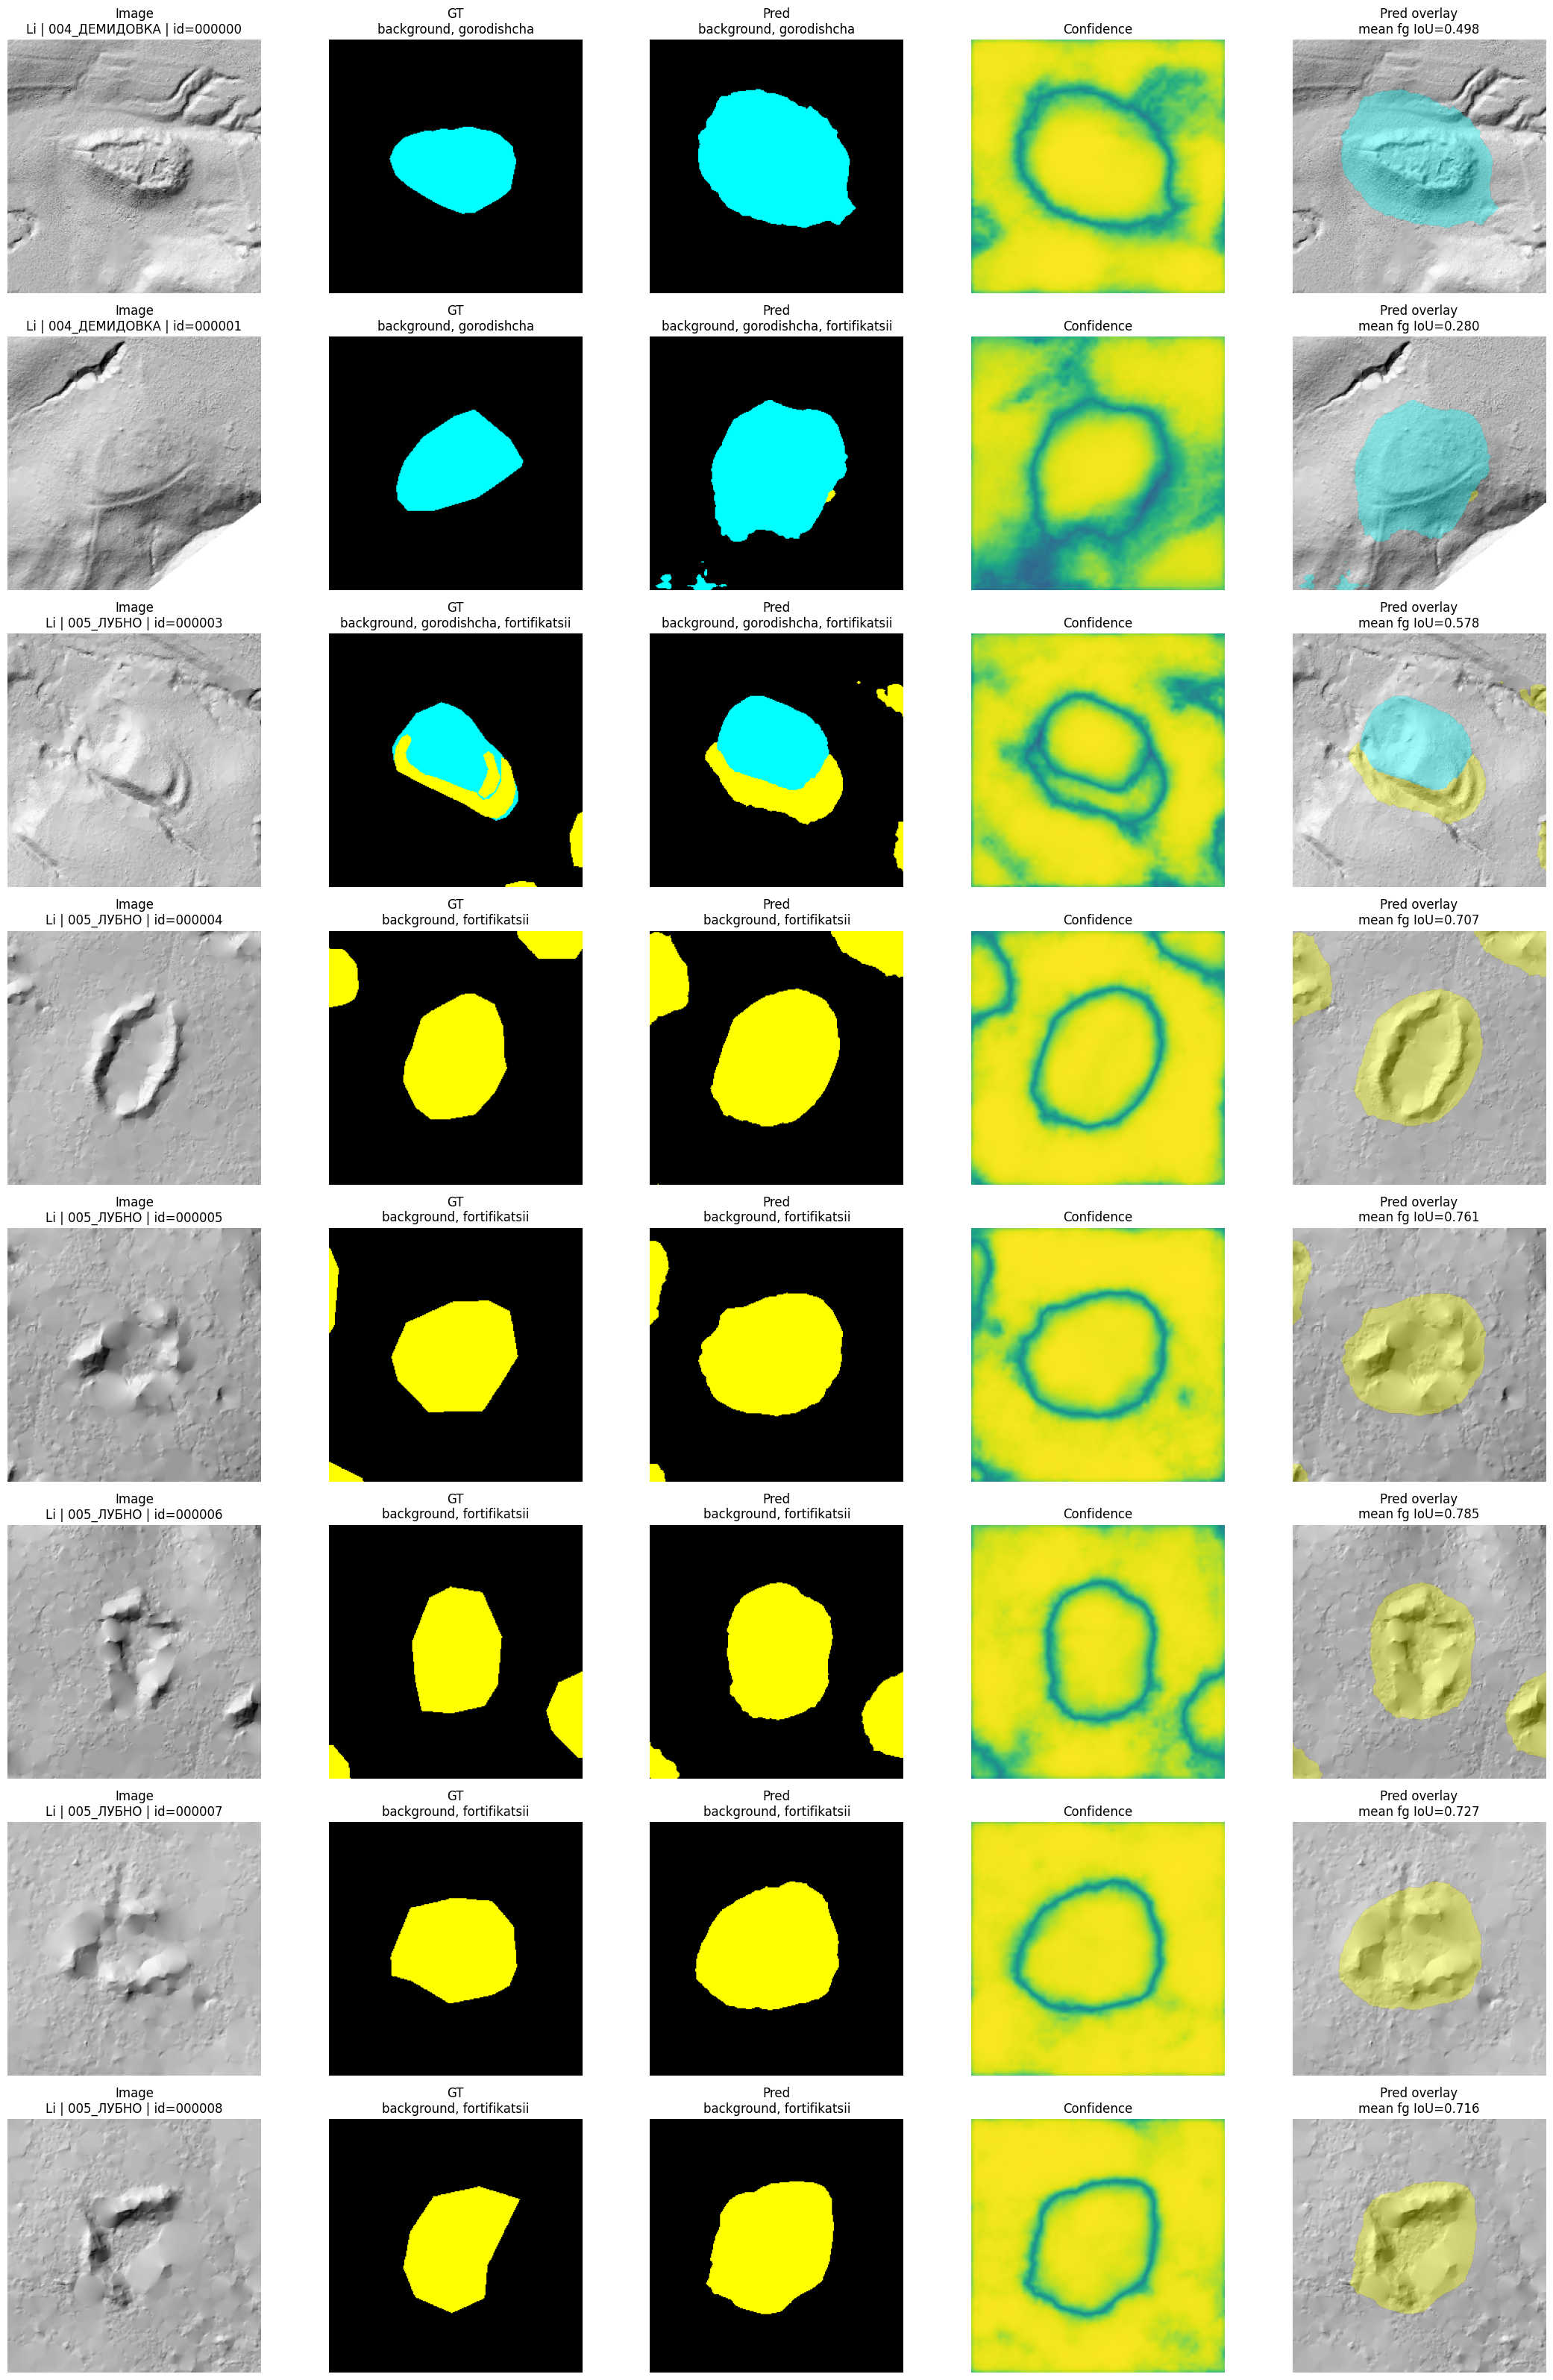

In [67]:
##### import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from matplotlib.colors import ListedColormap, BoundaryNorm


CLASS_NAMES = {
    0: "background",
    1: "kurgany_tselye",
    2: "kurgany_povrezhdennye",
    3: "gorodishcha",
    4: "fortifikatsii",
    5: "arkhitektury",
}

NUM_CLASSES = len(CLASS_NAMES)

MASK_CMAP = ListedColormap([
    "black",
    "lime",
    "red",
    "cyan",
    "yellow",
    "magenta",
])

MASK_NORM = BoundaryNorm(np.arange(-0.5, NUM_CLASSES + 0.5, 1), MASK_CMAP.N)

OVERLAY_RGBA = {
    1: [0.0, 1.0, 0.0, 0.35],
    2: [1.0, 0.0, 0.0, 0.35],
    3: [0.0, 1.0, 1.0, 0.35],
    4: [1.0, 1.0, 0.0, 0.35],
    5: [1.0, 0.0, 1.0, 0.35],
}


def denormalize_for_display(img):
    img = img.copy()
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min < 1e-6:
        return img * 0.0
    return (img - img_min) / (img_max - img_min)


def mask_to_overlay_multiclass(mask):
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    for class_id, rgba in OVERLAY_RGBA.items():
        overlay[mask == class_id] = rgba
    return overlay


def multiclass_iou_per_sample(gt, pred, num_classes=NUM_CLASSES):
    ious = {}

    for cls_id in range(1, num_classes):  # без background
        gt_c = gt == cls_id
        pr_c = pred == cls_id

        union = np.logical_or(gt_c, pr_c).sum()
        inter = np.logical_and(gt_c, pr_c).sum()

        if union == 0:
            ious[cls_id] = np.nan
        else:
            ious[cls_id] = inter / (union + 1e-6)

    valid = [v for v in ious.values() if not np.isnan(v)]
    mean_fg_iou = float(np.mean(valid)) if valid else np.nan

    return mean_fg_iou, ious


def visualize_batch_multiclass(model, loader, device, max_samples=8, save_path=None):
    model.eval()

    batch = next(iter(loader))
    images = batch["image"].to(device)
    masks = batch["mask"].to(device)

    with torch.no_grad():
        logits = model(images)                 # [B, C, H, W]
        probs = torch.softmax(logits, dim=1)   # [B, C, H, W]
        preds = torch.argmax(probs, dim=1)     # [B, H, W]
        confs = torch.max(probs, dim=1).values # [B, H, W]

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()
    confs = confs.cpu()

    sample_ids = batch["sample_id"]
    regions = batch["region"]
    modalities = batch["modality"]

    n = min(max_samples, images.shape[0])
    fig, axes = plt.subplots(n, 5, figsize=(22, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = images[i, 0].numpy()
        gt = masks[i].numpy()
        pr = preds[i].numpy()
        conf = confs[i].numpy()

        img_show = denormalize_for_display(img)

        mean_iou, ious = multiclass_iou_per_sample(gt, pr)

        gt_classes = [CLASS_NAMES[int(c)] for c in np.unique(gt)]
        pr_classes = [CLASS_NAMES[int(c)] for c in np.unique(pr)]

        axes[i][0].imshow(img_show, cmap="gray")
        axes[i][0].set_title(
            f"Image\n{modalities[i]} | {regions[i]} | id={sample_ids[i]}"
        )
        axes[i][0].axis("off")

        axes[i][1].imshow(gt, cmap=MASK_CMAP, norm=MASK_NORM)
        axes[i][1].set_title("GT\n" + ", ".join(gt_classes))
        axes[i][1].axis("off")

        axes[i][2].imshow(pr, cmap=MASK_CMAP, norm=MASK_NORM)
        axes[i][2].set_title("Pred\n" + ", ".join(pr_classes))
        axes[i][2].axis("off")

        axes[i][3].imshow(conf, cmap="viridis", vmin=0, vmax=1)
        axes[i][3].set_title("Confidence")
        axes[i][3].axis("off")

        overlay = mask_to_overlay_multiclass(pr)

        axes[i][4].imshow(img_show, cmap="gray")
        axes[i][4].imshow(overlay)
        axes[i][4].set_title(f"Pred overlay\nmean fg IoU={mean_iou:.3f}")
        axes[i][4].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved visualization to {save_path}")

    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

val_dataset = ArcheologyDatasetMultiClass(
    meta_df=val_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

model = DeepLabMultiClass(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=NUM_CLASSES,
).to(device)

model.load_state_dict(
    torch.load("/kaggle/working/deeplab_5class_anticollapse_best.pth", map_location=device)
)

visualize_batch_multiclass(
    model=model,
    loader=train_eval_loader,
    device=device,
    max_samples=8,
    save_path="val_predictions_multiclass.png",
)

In [60]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

CLASS_NAMES = {
    0: "background",
    1: "kurgany_tselye",
    2: "kurgany_povrezhdennye",
    3: "gorodishcha",
    4: "fortifikatsii",
    5: "arkhitektury",
}

NUM_CLASSES = len(CLASS_NAMES)


@torch.no_grad()
def collect_confusion_matrix(model, loader, device, num_classes=NUM_CLASSES):
    model.eval()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        preds_flat = preds.view(-1).cpu()
        masks_flat = masks.view(-1).cpu()

        valid = (masks_flat >= 0) & (masks_flat < num_classes)
        preds_flat = preds_flat[valid]
        masks_flat = masks_flat[valid]

        idx = masks_flat * num_classes + preds_flat
        batch_cm = torch.bincount(idx, minlength=num_classes * num_classes)
        batch_cm = batch_cm.reshape(num_classes, num_classes)

        cm += batch_cm

    return cm.numpy()


def metrics_from_cm(cm):
    rows = []

    for cls_id, cls_name in CLASS_NAMES.items():
        tp = cm[cls_id, cls_id]
        fp = cm[:, cls_id].sum() - tp
        fn = cm[cls_id, :].sum() - tp

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        iou = tp / (tp + fp + fn + 1e-6)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-6)

        rows.append({
            "class_id": cls_id,
            "class_name": cls_name,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "precision": precision,
            "recall": recall,
            "iou": iou,
            "dice": dice,
        })

    return pd.DataFrame(rows)


cm = collect_confusion_matrix(model, val_loader, device)
metrics_df = metrics_from_cm(cm)

display(metrics_df)

,class_id,class_name,tp,fp,fn,precision,recall,iou,dice
0,0,background,24185807,4415975,4855130,0.845605,0.832818,0.722894,0.839163
1,1,kurgany_tselye,136452,746658,1165929,0.154513,0.104771,0.066593,0.124871
2,2,kurgany_povrezhdennye,1954063,4119736,2275177,0.321720,0.462036,0.234048,0.379318
3,3,gorodishcha,3425,298958,2312310,0.011327,0.001479,0.001310,0.002616
4,4,fortifikatsii,49713,1497158,236535,0.032138,0.173671,0.027875,0.054239
5,5,arkhitektury,10555,68092,301496,0.134207,0.033825,0.027766,0.054032


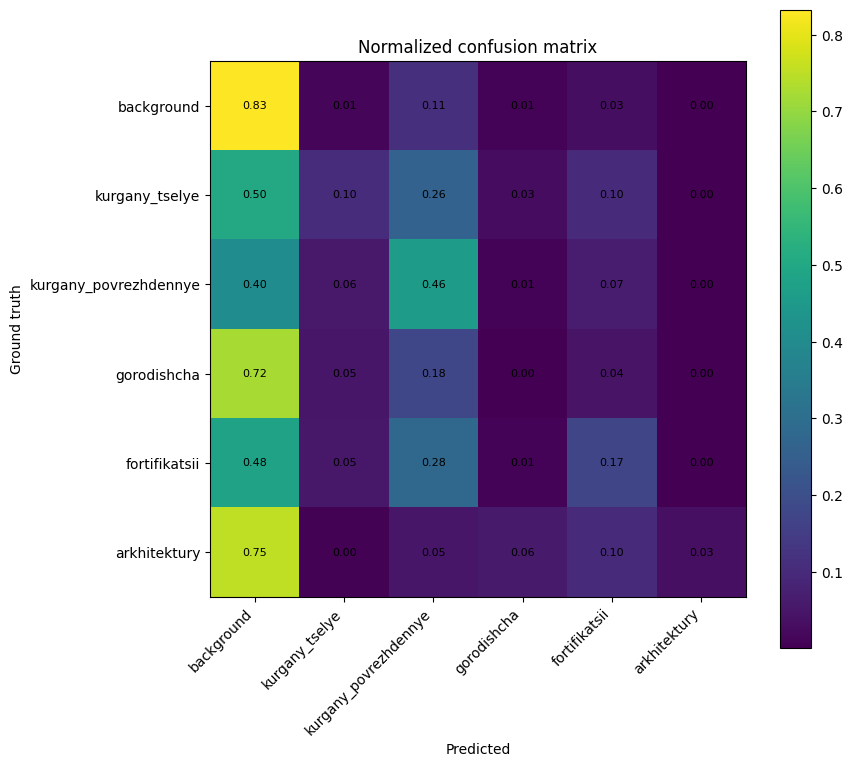

In [61]:
def plot_confusion_matrix(cm, normalize=True):
    cm_plot = cm.astype(np.float64)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = cm_plot / np.maximum(row_sums, 1)

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cm_plot)

    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)], rotation=45, ha="right")
    ax.set_yticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title("Normalized confusion matrix" if normalize else "Confusion matrix")

    fig.colorbar(im, ax=ax)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            text = f"{cm_plot[i, j]:.2f}" if normalize else str(int(cm_plot[i, j]))
            ax.text(j, i, text, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, normalize=True)

In [62]:
import cv2
from shapely.geometry import Polygon, mapping
from shapely.validation import make_valid

def mask_to_polygons(mask, class_id, min_area=8):
    binary = (mask == class_id).astype(np.uint8)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    polygons = []

    for cnt in contours:
        if len(cnt) < 3:
            continue

        coords = cnt[:, 0, :].astype(float)

        poly = Polygon(coords)

        if not poly.is_valid:
            poly = make_valid(poly)

        if poly.is_empty:
            continue

        if poly.geom_type == "MultiPolygon":
            geoms = list(poly.geoms)
        else:
            geoms = [poly]

        for p in geoms:
            if p.area >= min_area:
                polygons.append(p)

    return polygons


@torch.no_grad()
def build_patch_geojsons_for_competition_metric(
    model,
    loader,
    device,
    min_area=8,
):
    model.eval()

    pred_features = []
    gt_features = []

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].cpu().numpy()

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()

        sample_ids = batch["sample_id"]

        for b in range(images.shape[0]):
            sample_id = str(sample_ids[b])

            gt_mask = masks[b]
            pred_mask = preds[b]

            for class_id in range(1, NUM_CLASSES):
                class_name = CLASS_NAMES[class_id]

                # GT
                for poly in mask_to_polygons(gt_mask, class_id, min_area):
                    gt_features.append({
                        "type": "Feature",
                        "geometry": mapping(poly),
                        "properties": {
                            "region_name": sample_id,
                            "class_name": class_name,
                            "confidence": 1.0,
                        },
                    })

                # PRED
                for poly in mask_to_polygons(pred_mask, class_id, min_area):
                    pred_features.append({
                        "type": "Feature",
                        "geometry": mapping(poly),
                        "properties": {
                            "region_name": sample_id,
                            "class_name": class_name,
                            "confidence": 1.0,
                        },
                    })

    return (
        {"type": "FeatureCollection", "features": pred_features},
        {"type": "FeatureCollection", "features": gt_features},
    )

In [63]:
import math
from shapely.geometry import Polygon, MultiPolygon, Point, shape
from shapely.validation import make_valid

CLASS_WEIGHTS = {
    "kurgany_povrezhdennye": 27.8,
    "kurgany_tselye": 22.2,
    "gorodishcha": 16.7,
    "arkhitektury": 11.1,
    "fortifikatsii": 5.6,
}

TARGET_CLASSES = list(CLASS_WEIGHTS.keys())


def _extract_polygon(feature):
    try:
        geom = shape(feature["geometry"])
        if not geom.is_valid:
            geom = make_valid(geom)

        if isinstance(geom, MultiPolygon):
            geom = max(geom.geoms, key=lambda p: p.area)

        if isinstance(geom, Polygon) and geom.is_valid and not geom.is_empty:
            return geom
    except Exception:
        return None
    return None


def _confidence(feature):
    try:
        return float(feature.get("properties", {}).get("confidence", 1.0))
    except Exception:
        return 1.0


def _polygon_iou(a, b):
    try:
        inter = a.intersection(b).area
        union = a.union(b).area
        return inter / union if union > 0 else 0.0
    except Exception:
        return 0.0


def _centroid_hit(pred_poly, gt_poly):
    try:
        c = pred_poly.centroid
        return gt_poly.contains(c) or gt_poly.boundary.distance(c) < 1e-10
    except Exception:
        return False


def collect_by_class(geojson_data):
    out = {cls: [] for cls in TARGET_CLASSES}

    for feat in geojson_data.get("features", []):
        props = feat.get("properties", {}) or {}
        cls = props.get("class_name")

        if cls not in TARGET_CLASSES:
            continue

        poly = _extract_polygon(feat)
        if poly is None:
            continue

        out[cls].append((poly, _confidence(feat)))

    return out


def soft_match(preds, gts, iou_threshold=0.3):
    if not preds and not gts:
        return 0, 0, 0
    if not preds:
        return 0, 0, len(gts)
    if not gts:
        return 0, len(preds), 0

    preds = sorted(preds, key=lambda x: x[1], reverse=True)

    matched_gt = set()
    tp = 0

    for pred_poly, conf in preds:
        best_iou = -1
        best_j = -1

        for j, (gt_poly, _) in enumerate(gts):
            if j in matched_gt:
                continue

            iou = _polygon_iou(pred_poly, gt_poly)
            centroid = _centroid_hit(pred_poly, gt_poly)

            if iou > iou_threshold or centroid:
                if iou > best_iou:
                    best_iou = iou
                    best_j = j

        if best_j >= 0:
            matched_gt.add(best_j)
            tp += 1

    fp = len(preds) - tp
    fn = len(gts) - tp
    return tp, fp, fn


def competition_like_f1(pred_geojson, gt_geojson, iou_threshold=0.3):
    pred_by_class = collect_by_class(pred_geojson)
    gt_by_class = collect_by_class(gt_geojson)

    rows = []
    weighted_sum = 0.0
    weight_sum = 0.0

    for cls in TARGET_CLASSES:
        preds = pred_by_class.get(cls, [])
        gts = gt_by_class.get(cls, [])

        tp, fp, fn = soft_match(preds, gts, iou_threshold=iou_threshold)

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        w = CLASS_WEIGHTS[cls]
        weighted_sum += f1 * w
        weight_sum += w

        rows.append({
            "class_name": cls,
            "weight": w,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "num_predictions": len(preds),
            "num_ground_truth": len(gts),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    final_score = weighted_sum / weight_sum

    return final_score, pd.DataFrame(rows)

In [64]:
# 1. строим geojson
pred_geojson, gt_geojson = build_patch_geojsons_for_competition_metric(
    model, val_loader, device
)

# 2. считаем метрику
final_score, comp_df = competition_like_f1(
    pred_geojson,
    gt_geojson,
    iou_threshold=0.3,
)

print("competition-like final_score:", final_score)
display(comp_df)

competition-like final_score: 0.5266909545202405


,class_name,weight,tp,fp,fn,num_predictions,num_ground_truth,precision,recall,f1
0,kurgany_povrezhdennye,27.8,927,0,1408,927,2335,1.000000,0.397002,0.568363
1,kurgany_tselye,22.2,435,25,554,460,989,0.945652,0.439838,0.600414
2,gorodishcha,16.7,38,80,2,118,40,0.322034,0.950000,0.481012
3,arkhitektury,11.1,53,7,131,60,184,0.883333,0.288043,0.434426
4,fortifikatsii,5.6,117,425,16,542,133,0.215867,0.879699,0.346666


In [65]:
import json


with open("val_patch_predictions.geojson", "w", encoding="utf-8") as f:
    json.dump(pred_geojson, f, ensure_ascii=False)

with open("val_patch_ground_truth.geojson", "w", encoding="utf-8") as f:
    json.dump(gt_geojson, f, ensure_ascii=False)
    
out = {
    "final_score": float(final_score),
    "per_class": comp_df.to_dict(orient="records"),
}

with open("val_patch_competition_metric.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

In [66]:
print(final_score)
display(comp_df)

0.5266909545202405


,class_name,weight,tp,fp,fn,num_predictions,num_ground_truth,precision,recall,f1
0,kurgany_povrezhdennye,27.8,927,0,1408,927,2335,1.000000,0.397002,0.568363
1,kurgany_tselye,22.2,435,25,554,460,989,0.945652,0.439838,0.600414
2,gorodishcha,16.7,38,80,2,118,40,0.322034,0.950000,0.481012
3,arkhitektury,11.1,53,7,131,60,184,0.883333,0.288043,0.434426
4,fortifikatsii,5.6,117,425,16,542,133,0.215867,0.879699,0.346666
